<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/CATBoostreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
!pip install catboost -q

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import lightgbm as lgb
import xgboost as xgb
import warnings
from sklearn.datasets import load_iris
warnings.filterwarnings('ignore')


In [96]:
# # loading the data
# iris = load_iris()
# X = iris.data
# y = iris.target
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# #

In [97]:
# from catboost.core import CatBoostClassifier
# # initializing the model
# model=CatBoostClassifier(learning_rate=0.3,iterations=100,depth=6,verbose=0)
# #

In [98]:
# # predict the data
# model.fit(X_train,y_train)
# y_pred=model.predict(X_test)

In [99]:
# accuracy=model.score(X_test,y_test)
# print(f"Accuracy: {accuracy:.2f}")

In [100]:
# read  data from csv file
df=pd.read_csv("House_Rent_Dataset.csv")


In [101]:
# preview the oveall data
# previewing the column info and row info
# Display summary information about the DataFrame 'df'
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None


In [102]:
# preview the tp data of the dataset
print(df.head())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

In [103]:
# previewing the shape
print(df.shape)

(4746, 12)


In [104]:
# Generate summary statistics of the DataFrame 'df'
print(df.describe())

               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75%       3.000000  3.300000e+04  1200.000000     2.000000
max       6.000000  3.500000e+06  8000.000000    10.000000


In [105]:
# Exploratory Data Analysis (EDA):
# EDA is an approach to analyzing the data using visual techniques.
# It is used to discover trends, and patterns, or to check assumptions with the help of statistical summaries and graphical representations.
# While performing the EDA of this dataset we will try to look at what is the relation between the independent features that is how one affects the other.

# Identify and collect categorical columns with less than 10 unique values
# Initialize an empty list to store categorical columns

cat_cols=[]

# iterate through dataframe
for col in df.columns:
  if(df[col].dtype == 'object' and df[col].nunique() < 10):
    # add the column to the list
    cat_cols.append(col)

# Print the categorical columns
cat_cols += ['BHK', 'Bathroom']
cat_cols


['Area Type',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact',
 'BHK',
 'Bathroom']

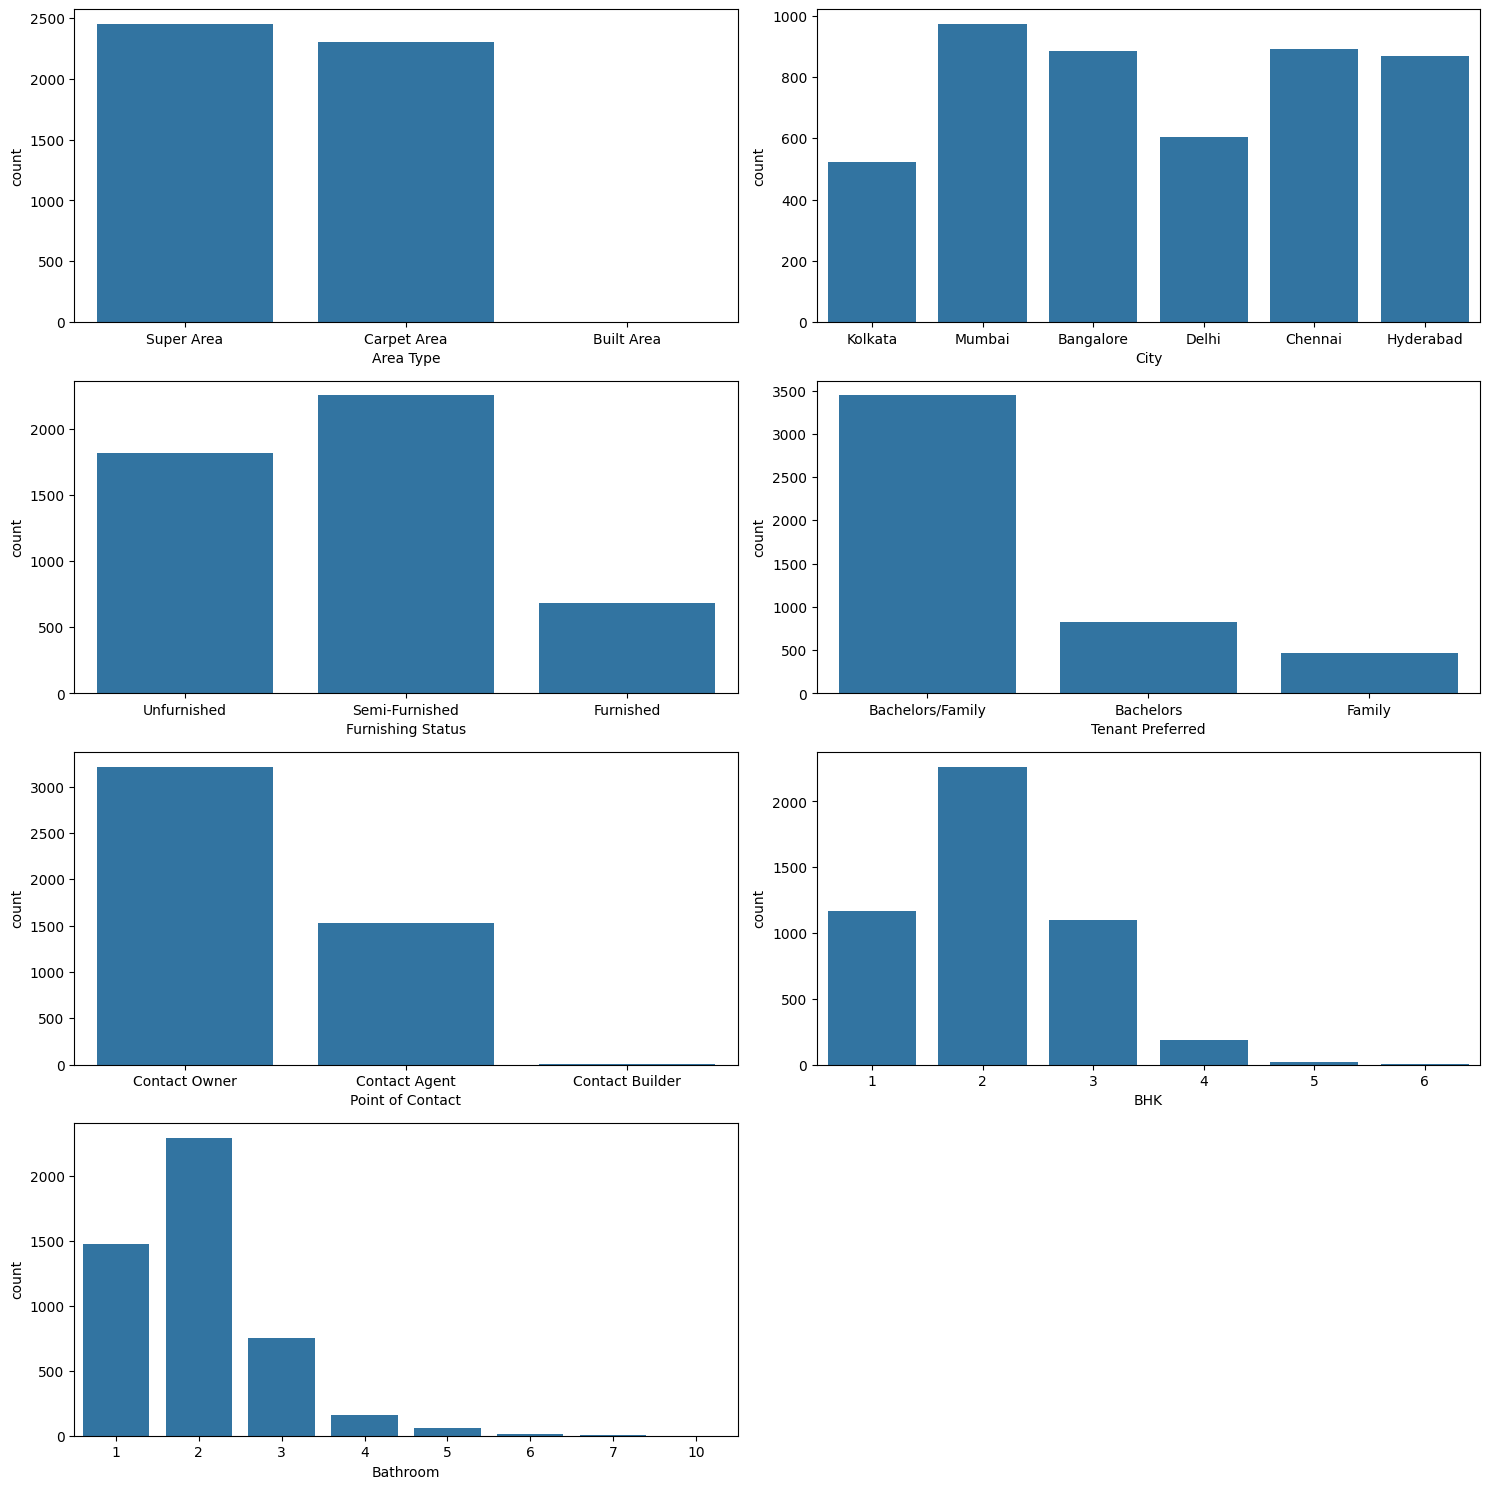

In [106]:
# Create subplots to display count plots for categorical columns in 'cat_cols'
# Subplots are arranged in a 4x2 grid, and
# each subplot shows the count distribution of a categorical column.

plt.figure(figsize=(15, 15))
for i,col in enumerate(cat_cols):
    plt.subplot(4,2,i+1)
    sb.countplot(x=col,data=df)
plt.tight_layout()
#display sub plot
plt.show()

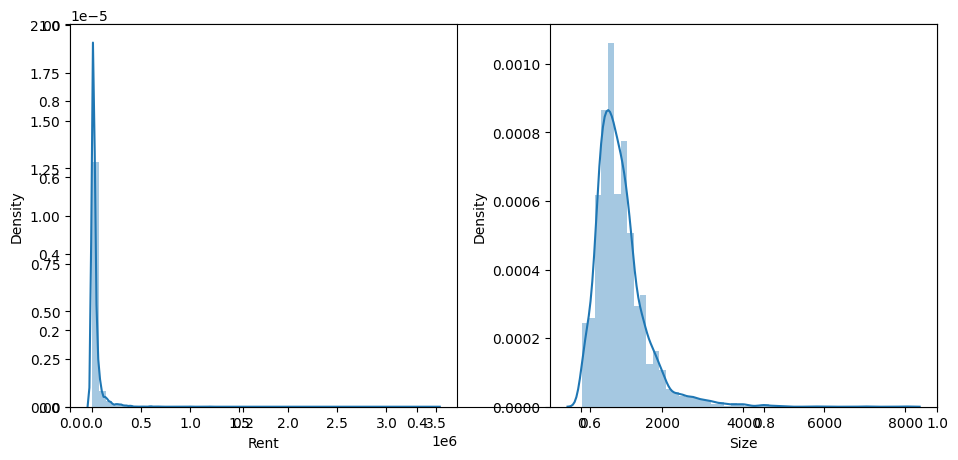

In [107]:
# Create subplots to display distribution plots for numeric columns in 'num_cols'
num_cols = ['Rent', 'Size']
plt.subplots(figsize=(10, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

In [108]:
# Remove unnecessary columns
# ('Posted On', 'Floor', 'Area Locality') from the DataFrame 'df'
df.drop(['Posted On', 'Floor', 'Area Locality'],inplace=True,axis=1)

# For each categorical column in 'cat_cols',
# calculate and print the mean rent for each category
for i,col in enumerate(cat_cols):
  print(df[[col,'Rent']].groupby(col).mean())
  print()

                     Rent
Area Type                
Built Area   10500.000000
Carpet Area  52385.897302
Super Area   18673.396566

                   Rent
City                   
Bangalore  24966.365688
Chennai    21614.092031
Delhi      29461.983471
Hyderabad  20555.048387
Kolkata    11645.173664
Mumbai     85321.204733

                           Rent
Furnishing Status              
Furnished          56110.305882
Semi-Furnished     38718.810751
Unfurnished        22461.635813

                          Rent
Tenant Preferred              
Bachelors         42143.793976
Bachelors/Family  31210.792683
Family            50020.341102

                          Rent
Point of Contact              
Contact Agent     73481.158927
Contact Builder    5500.000000
Contact Owner     16704.206468

              Rent
BHK               
1     14139.223650
2     22113.864018
3     55863.062842
4    168864.555556
5    297500.000000
6     73125.000000

                   Rent
Bathroom               
1 

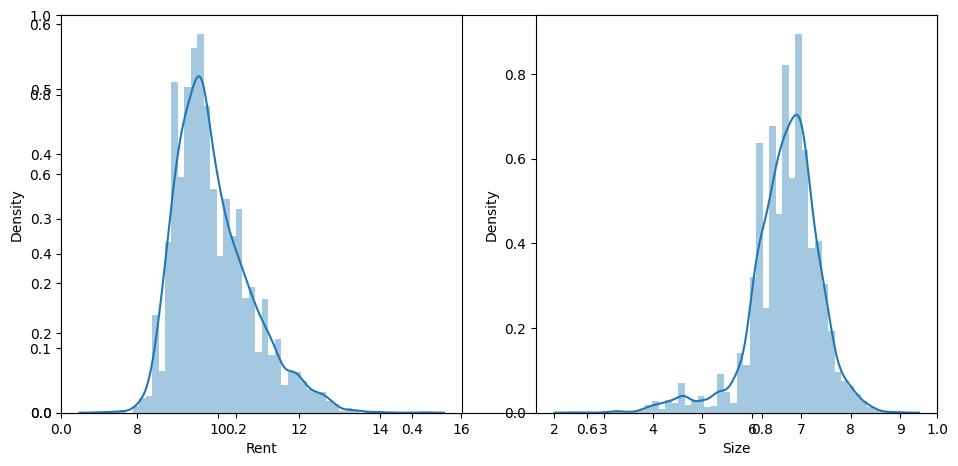

In [109]:
# Data Preprocessing
# Data preprocessing is a very crucial in any ML development lifecycle as we know
# that the real world dataset is untidy
# and before making any use of it we will have to convert it into structural
# form and use it in a manner so, that some value can be bring out of it.
# In this process first with the current data we will apply the logarithmic transformation on the rent
# and the size columsn as they are not normally distributed but they are left skewed distributions.
# Log-transform the 'Rent' and 'Size' columns using np.log1p to reduce skewness

num_cols = ['Rent', 'Size']
df[num_cols] = np.log1p(df[num_cols])

plt.subplots(figsize=(10, 5))
for i,cols in enumerate(num_cols):
  plt.subplot(1,2,i+1)
  sb.distplot(df[cols])
plt.tight_layout()
# Dispay the plot
plt.show()



In [110]:
# one hot Encoding
cat_cols = ['Area Type', 'City', 'Furnishing Status',
            'Point of Contact', 'Tenant Preferred']
for col in cat_cols:
  temp = pd.get_dummies(df[col]).astype('int')
  df=pd.concat([df,temp],axis=1)
df.drop(cat_cols, axis=1, inplace=True)
print(df.head())


   BHK      Rent      Size  Bathroom  Built Area  Carpet Area  Super Area  \
0    2  9.210440  7.003974         2           0            0           1   
1    2  9.903538  6.685861         1           0            0           1   
2    2  9.741027  6.908755         1           0            0           1   
3    2  9.210440  6.685861         1           0            0           1   
4    2  8.922792  6.746412         1           0            1           0   

   Bangalore  Chennai  Delhi  ...  Mumbai  Furnished  Semi-Furnished  \
0          0        0      0  ...       0          0               0   
1          0        0      0  ...       0          0               1   
2          0        0      0  ...       0          0               1   
3          0        0      0  ...       0          0               0   
4          0        0      0  ...       0          0               0   

   Unfurnished  Contact Agent  Contact Builder  Contact Owner  Bachelors  \
0            1              

In [111]:
# Splitting Data
features = df.drop('Rent', axis=1)  # Features (independent variables)
target = df['Rent']  # Target variable (dependent variable)

# Splitting the data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    features, target, random_state=2023, test_size=0.15)

# Display the shapes of the training and validation sets
X_train.shape, X_val.shape

((4034, 21), (712, 21))

In [112]:
# Train an model
# Model Development
# catboost regression model
# CatBoost Regression Model
from catboost import CatBoostRegressor

# Initialize the CatBoostRegressor with RMSE as the loss function
model = CatBoostRegressor(loss_function='RMSE')

# Fit the model on the training data with verbose logging every 100 iterations
model.fit(X_train, Y_train, verbose=100)




Learning rate set to 0.051037
0:	learn: 0.8976462	total: 1.65ms	remaining: 1.64s
100:	learn: 0.3741647	total: 134ms	remaining: 1.19s
200:	learn: 0.3571139	total: 306ms	remaining: 1.22s
300:	learn: 0.3455686	total: 511ms	remaining: 1.19s
400:	learn: 0.3369937	total: 792ms	remaining: 1.18s
500:	learn: 0.3305270	total: 941ms	remaining: 937ms
600:	learn: 0.3252100	total: 1.07s	remaining: 712ms
700:	learn: 0.3200064	total: 1.29s	remaining: 552ms
800:	learn: 0.3153692	total: 1.51s	remaining: 377ms
900:	learn: 0.3116973	total: 1.7s	remaining: 187ms
999:	learn: 0.3082544	total: 1.84s	remaining: 0us


CatBoostRegressor(loss_function='RMSE')

In [113]:
# Import the mean squared error (MSE) function from sklearn and alias it as 'mse'
from sklearn.metrics import mean_squared_error as mse

# Generate predictions on the training and validation sets using the trained 'model'
y_train = model.predict(X_train)
y_val = model.predict(X_val)

# Calculate and print the Root Mean Squared Error (RMSE) for training and validation sets
print("Training RMSE: ", np.sqrt(mse(Y_train, y_train)))
print("Validation RMSE: ", np.sqrt(mse(Y_val, y_val)))


Training RMSE:  0.30825437763617797
Validation RMSE:  0.39986332453193896


In [1]:
# In this regression study employing CatBoost, we took advantage
# of the CatBoostRegressor's capacity to forecast continuous numerical values
# from structured data. The preprocessing phase is made simpler by CatBoost's
# skillful handling of categorical information. We set up the model hyperparameters
# carefully, made sure the training and validation procedures worked, and prepared
# the data methodically. We created a robust regression model by using feature
# engineering to assess the model's performance using measures like RMSE. For
# precise regression predictions across a variety of structured datasets,
# CatBoost's automatic category encoding,
# regularization techniques, and gradient boosting power make it an appealing option.